# BTP Mid-Evaluation (50%) — Live Demonstration
## High-Performance Fronthaul Load Management in 5G/6G C-RAN

**Target:** IEEE TWC / JSAC &nbsp;·&nbsp; **Stage:** Mid-Term 50% &nbsp;·&nbsp; **Date:** September 2026

| Proposed | Idea | Complexity |
|---|---|---|
| **CSEE** | Delay-domain top-K + BFP | $O(MN\log N)$ |
| **RAS-BFP** | SRHT sketch + QR + BFP | $O(rMN)$ |
| **ACAFS** | Rank → Split 7.2x / 7.1 / 6 | $O(M)$ / UE |

## 1. Imports

In [1]:
import sys, os, time
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from src.channel.tdl_a import TDLAChannel, ChannelConfig, estimate_rank
from src.encoder.bfp import bfp_encode, bfp_decode, bfp_bits_used
from src.encoder.svd_encoder import SVDEncoder
from src.encoder.csee import CSEEEncoder
from src.encoder.ras_bfp import RASBFPEncoder
from src.split.acafs import ACAFSController, FunctionalSplit
from src.metrics.nmse import nmse, compression_ratio, original_bits

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
print("✓ All BTP modules imported.")

✓ All BTP modules imported.


## 2. 3GPP TDL-A Channel Realization ($M=64$, $N=1200$)

H shape: (64, 1200)   Y shape: (64, 1200)
||Y||_F = 278.40
Estimated numerical rank (99% energy): 6


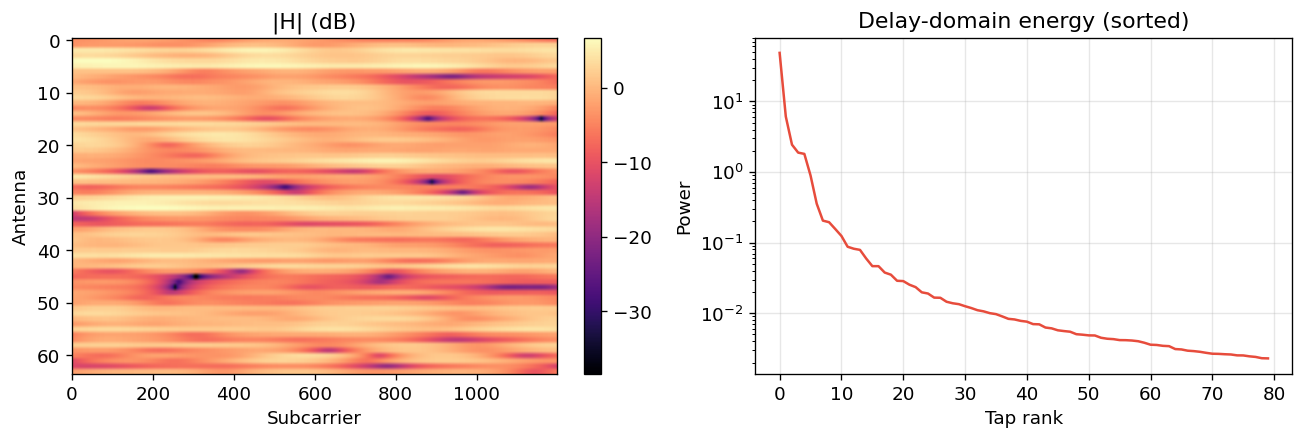

In [2]:
cfg = ChannelConfig(M=64, N=1200, SNR_dB=20.0, seed=42)
channel = TDLAChannel(cfg)
H = channel.generate_H()
Y = channel.generate_received_signal(H, seed_offset=0, pilots=True)
r_est = estimate_rank(Y)

print(f"H shape: {H.shape}   Y shape: {Y.shape}")
print(f"||Y||_F = {np.linalg.norm(Y, 'fro'):.2f}")
print(f"Estimated numerical rank (99% energy): {r_est}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
im0 = axes[0].imshow(20*np.log10(np.abs(H)+1e-12), aspect="auto", cmap="magma")
axes[0].set_title("|H| (dB)"); axes[0].set_xlabel("Subcarrier"); axes[0].set_ylabel("Antenna")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

Yd = np.fft.ifft(Y, axis=1)
pwr = np.sum(np.abs(Yd)**2, axis=0)
axes[1].semilogy(np.sort(pwr)[::-1][:80], color="#e74c3c")
axes[1].set_title("Delay-domain energy (sorted)")
axes[1].set_xlabel("Tap rank"); axes[1].set_ylabel("Power")
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Single-Slot Encoding Benchmark

In [3]:
orig_b = original_bits(cfg.M, cfg.N)

def time_ms(fn, reps=7):
    ts = []
    for _ in range(reps):
        t0 = time.perf_counter(); fn(); ts.append((time.perf_counter()-t0)*1000)
    return float(np.median(ts))

rows = []

# BFP
enc = bfp_encode(Y, bits=8); Yh = bfp_decode(enc)
rows.append({"Method": "O-RAN BFP (b=8)",
             "NMSE (dB)": nmse(Y, Yh),
             "CR": compression_ratio(orig_b, bfp_bits_used(enc)),
             "Encode (ms)": time_ms(lambda: bfp_encode(Y, bits=8)),
             "Theory": "Empirical"})

# SVD
svd = SVDEncoder(r=12, bits=10)
enc = svd.encode(Y); Yh = svd.decode(enc)
rows.append({"Method": "Truncated SVD (r=12)",
             "NMSE (dB)": nmse(Y, Yh),
             "CR": svd.compression_ratio(enc),
             "Encode (ms)": time_ms(lambda: svd.encode(Y)),
             "Theory": "Eckart–Young"})

# CSEE
csee = CSEEEncoder(K=300, bits=10)
enc = csee.encode(Y); Yh = csee.decode(enc)
bound = 10*np.log10(CSEEEncoder.theoretical_nmse_bound(Y, 300, 10)+1e-20)
rows.append({"Method": "CSEE (K=300) ★",
             "NMSE (dB)": nmse(Y, Yh),
             "CR": csee.compression_ratio(enc),
             "Encode (ms)": time_ms(lambda: csee.encode(Y)),
             "Theory": f"Thm1 ≤ {bound:.1f} dB"})

# RAS-BFP
ras = RASBFPEncoder(r=12, bits=10)
enc = ras.encode(Y); Yh = ras.decode(enc)
rows.append({"Method": "RAS-BFP (r=12) ★",
             "NMSE (dB)": nmse(Y, Yh),
             "CR": ras.compression_ratio(enc),
             "Encode (ms)": time_ms(lambda: ras.encode(Y)),
             "Theory": "Thm 2–4"})

df = pd.DataFrame(rows)
df["NMSE (dB)"] = df["NMSE (dB)"].map(lambda x: f"{x:.2f}")
df["CR"] = df["CR"].map(lambda x: f"{x:.2f}×")
df["Encode (ms)"] = df["Encode (ms)"].map(lambda x: f"{x:.2f}")
display(df)

svd_t = float(df.loc[df["Method"].str.contains("SVD"), "Encode (ms)"].iloc[0])
print("\nSpeedup vs SVD:")
for _, row in df.iterrows():
    t = float(row["Encode (ms)"])
    print(f"  {row['Method']}: {svd_t/max(t,1e-9):.1f}×")

,Method,NMSE (dB),CR,Encode (ms),Theory
0,O-RAN BFP (b=8),-46.46,3.88×,3.97,Empirical
1,Truncated SVD (r=12),-21.06,16.17×,3484.73,Eckart–Young
2,CSEE (K=300) ★,-20.87,12.67×,14.07,Thm1 ≤ -21.0 dB
3,RAS-BFP (r=12) ★,-17.76,16.19×,24.09,Thm 2–4



Speedup vs SVD:
  O-RAN BFP (b=8): 877.8×
  Truncated SVD (r=12): 1.0×
  CSEE (K=300) ★: 247.7×
  RAS-BFP (r=12) ★: 144.7×


## 4. ACAFS Rank-Adaptive Functional Split

In [4]:
acafs = ACAFSController(tau_low=0.15, tau_high=0.55, M=64)
demo_ranks = np.array([4, 8, 12, 20, 28, 40, 48, 56])
splits = acafs.select_splits_batch(demo_ranks)
names = {FunctionalSplit.SPLIT_72x: "7.2x", FunctionalSplit.SPLIT_71: "7.1", FunctionalSplit.SPLIT_6: "6"}

demo = pd.DataFrame({
    "Rank r": demo_ranks,
    "r/M": np.round(demo_ranks/64, 3),
    "Selected Split": [names[s] for s in splits],
})
display(demo)

print(f"Theorem 5 analytical BW reduction vs Split 6: {acafs.theorem5_bound(64,0.15,0.55)*100:.1f}%")
print(f"Demo expected reduction: {acafs.expected_bw_reduction(demo_ranks)*100:.1f}%")
print("Split mix:", acafs.split_distribution(demo_ranks))

,Rank r,r/M,Selected Split
0,4,0.062,7.2x
1,8,0.125,7.2x
2,12,0.188,7.1
3,20,0.312,7.1
4,28,0.438,7.1
5,40,0.625,6
6,48,0.750,6
7,56,0.875,6


Theorem 5 analytical BW reduction vs Split 6: 33.2%
Demo expected reduction: 39.4%
Split mix: {'7.2x': 0.25, '7.1': 0.375, '6': 0.375}


## 5. Embedded Experiment Figures (Exp1–Exp4)

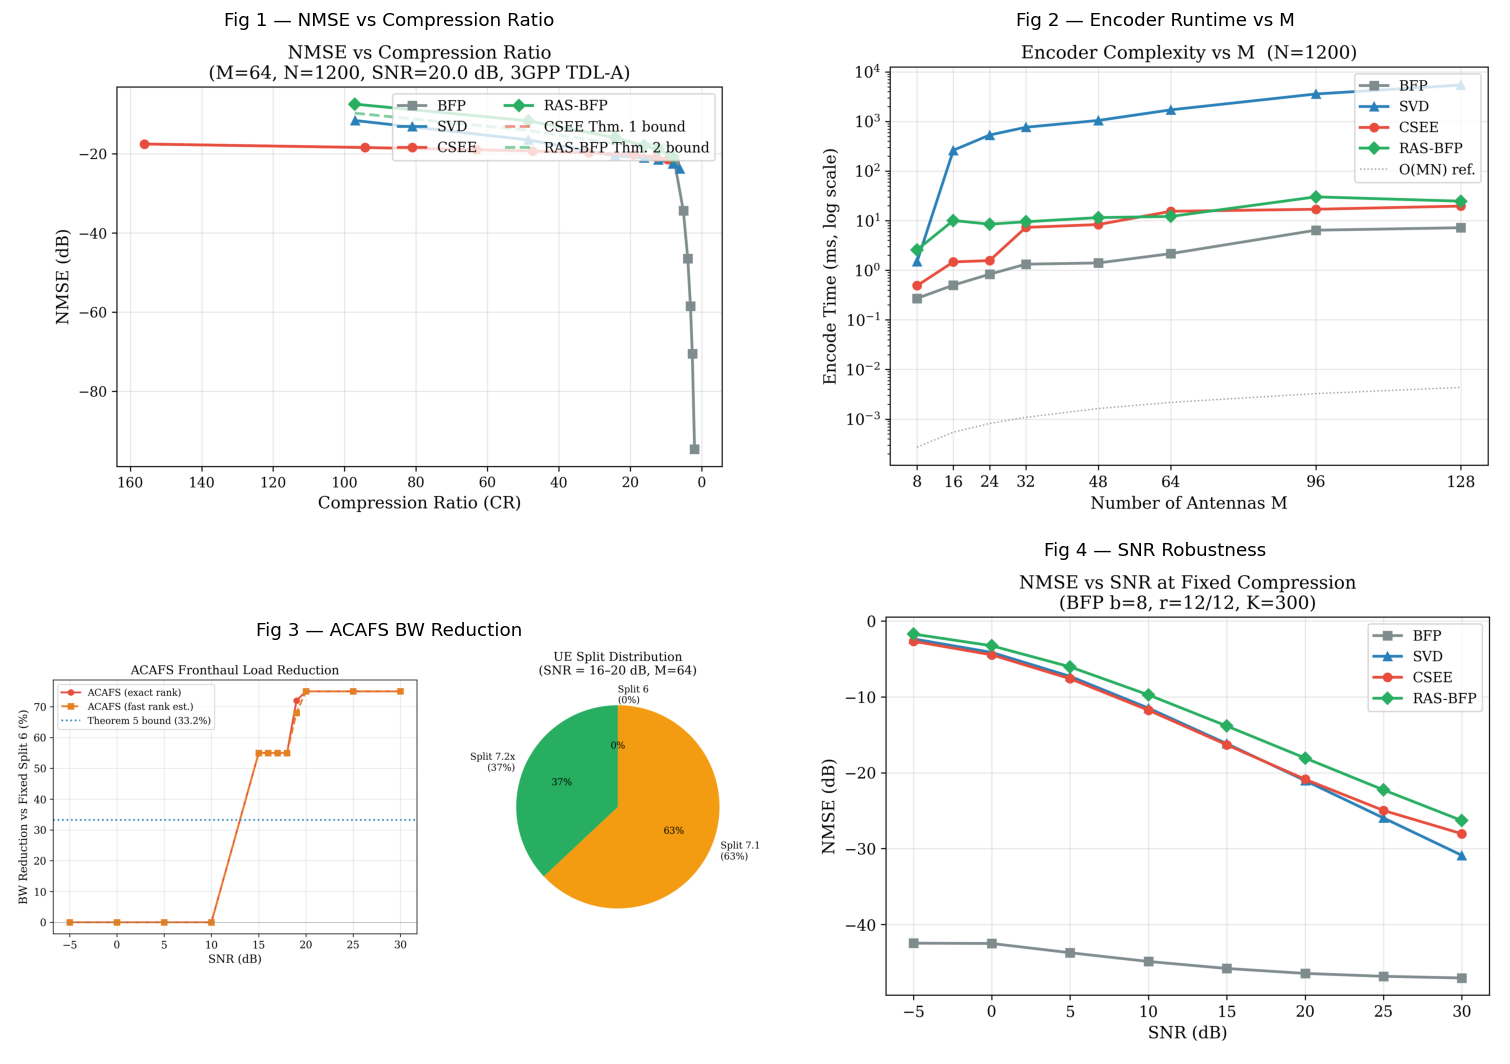

✓ Mid-evaluation demo complete — 50% milestone artifacts loaded.


In [5]:
fig_dir = os.path.join("..", "results", "figures")
files = [
    ("exp1_nmse_vs_cr.png", "Fig 1 — NMSE vs Compression Ratio"),
    ("exp2_complexity.png", "Fig 2 — Encoder Runtime vs M"),
    ("exp3_acafs.png", "Fig 3 — ACAFS BW Reduction"),
    ("exp4_snr_sweep.png", "Fig 4 — SNR Robustness"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (fname, title) in zip(axes.ravel(), files):
    path = os.path.join(fig_dir, fname)
    if os.path.exists(path):
        ax.imshow(plt.imread(path))
        ax.set_title(title, fontsize=11)
    else:
        ax.text(0.5, 0.5, f"Missing:\n{fname}", ha="center", va="center")
    ax.axis("off")
plt.tight_layout(); plt.show()
print("✓ Mid-evaluation demo complete — 50% milestone artifacts loaded.")